<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grid and field
N_grid = 256
x = np.linspace(0, 2*np.pi, N_grid, endpoint=False)
A = 0.1
sigma = 0.2
N = 100
centers = np.linspace(0, 2*np.pi, N, endpoint=False)

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

phi = sum(gaussian(c, sigma, A) for c in centers)
history = [phi.copy()]

# Evolution parameters (stabilized)
dt = 0.01
gamma = 0.005
lam = 0.1

def laplacian(phi):
    lap = np.roll(phi, 1) - 2*phi + np.roll(phi, -1)
    return np.nan_to_num(lap)

def evolve(phi):
    lap = laplacian(phi)
    nonlinear = lam * np.clip(phi, -1.0, 1.0)**3
    phi = phi + dt * (lap - gamma * phi + nonlinear)
    return np.clip(phi, -1.0, 1.0)

# Run and store snapshots
T = 300
snap_step = 25  # higher temporal resolution for tracking
snapshots = []
for t in range(T+1):
    phi = evolve(phi)
    if t % snap_step == 0:
        snapshots.append(phi.copy())


In [ ]:
def detect_peaks(phi, amp_thresh=0.06, min_separation=3):
    # Local maxima with periodic boundary
    is_peak = (phi > np.roll(phi, 1)) & (phi >= np.roll(phi, -1)) & (phi > amp_thresh)
    idx = np.where(is_peak)[0].tolist()
    # Enforce minimal separation by greedy filtering
    idx_sorted = sorted(idx, key=lambda i: -phi[i])
    kept = []
    occupied = np.zeros_like(phi, dtype=bool)
    for i in idx_sorted:
        # neighborhood mask
        neighborhood = [(i + k) % len(phi) for k in range(-min_separation, min_separation+1)]
        if not occupied[neighborhood].any():
            kept.append(i)
            occupied[neighborhood] = True
    kept = sorted(kept)
    return np.array(kept), phi[kept]


In [ ]:
def circular_distance(i, j, n):
    d = abs(i - j)
    return min(d, n - d)

def link_trajectories(snapshots, amp_thresh=0.06, link_radius=6):
    peaks_list = []
    amps_list = []
    for phi in snapshots:
        idx, amps = detect_peaks(phi, amp_thresh=amp_thresh)
        peaks_list.append(idx)
        amps_list.append(amps)

    # Initialize trajectories with t=0 peaks
    trajectories = [{'indices':[i], 'times':[0], 'amps':[amps_list[0][k]]}
                    for k, i in enumerate(peaks_list[0])]

    # Link forward
    n = len(snapshots[0])
    for t in range(1, len(snapshots)):
        current = peaks_list[t]
        current_used = np.zeros(len(current), dtype=bool)
        # Try to extend existing trajectories
        for traj in trajectories:
            last_idx = traj['indices'][-1]
            # find nearest current peak within link_radius
            if len(current) > 0:
                dists = np.array([circular_distance(last_idx, j, n) for j in current])
                k = np.argmin(dists) if len(dists) > 0 else None
                if k is not None and dists[k] <= link_radius and not current_used[k]:
                    traj['indices'].append(current[k])
                    traj['times'].append(t)
                    traj['amps'].append(snapshots[t][current[k]])
                    current_used[k] = True
                else:
                    # no match; trajectory pauses
                    pass
        # Start new trajectories from unmatched peaks
        for k in range(len(current)):
            if not current_used[k]:
                trajectories.append({'indices':[current[k]], 'times':[t], 'amps':[snapshots[t][current[k]]]})

    return trajectories, peaks_list, amps_list

trajectories, peaks_list, amps_list = link_trajectories(snapshots, amp_thresh=0.06, link_radius=6)


In [ ]:
# Convert snapshot index to physical time
times = np.arange(len(snapshots)) * snap_step

def traj_length(traj):
    # number of linked steps (not necessarily contiguous)
    return len(traj['times'])

def traj_span(traj):
    # time span in steps
    return (traj['times'][-1] - traj['times'][0]) if len(traj['times']) > 1 else 0

def traj_displacement(traj, n):
    if len(traj['indices']) < 2: return 0
    start = traj['indices'][0]; end = traj['indices'][-1]
    d = abs(end - start); return min(d, n - d)

def identity_consistency(traj):
    # amplitude variation coefficient
    amps = np.array(traj['amps'])
    m = np.mean(amps)
    return np.std(amps)/m if m > 0 else np.inf

n = N_grid
lengths = np.array([traj_length(tr) for tr in trajectories])
spans = np.array([traj_span(tr) for tr in trajectories]) * snap_step
displacements = np.array([traj_displacement(tr, n) for tr in trajectories]) * (2*np.pi / n)
consistency = np.array([identity_consistency(tr) for tr in trajectories])

# Summary statistics
metrics = {
    'count_trajectories': len(trajectories),
    'median_length': float(np.median(lengths)),
    'median_time_span': float(np.median(spans)),
    'median_displacement': float(np.median(displacements)),
    'median_consistency_cv': float(np.median(consistency))
}
print(metrics)


{'count_trajectories': 16, 'median_length': 12.0, 'median_time_span': 275.0, 'median_displacement': 0.01227184630308513, 'median_consistency_cv': 0.06245111263852421}


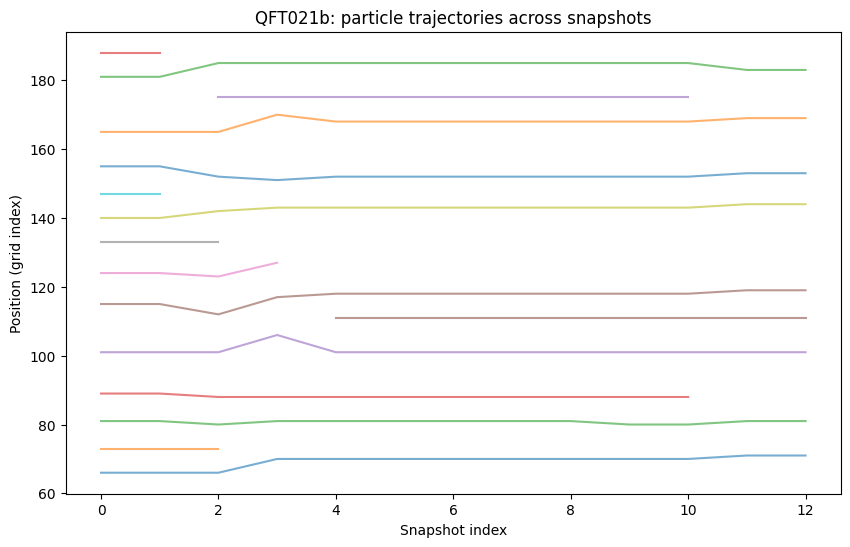

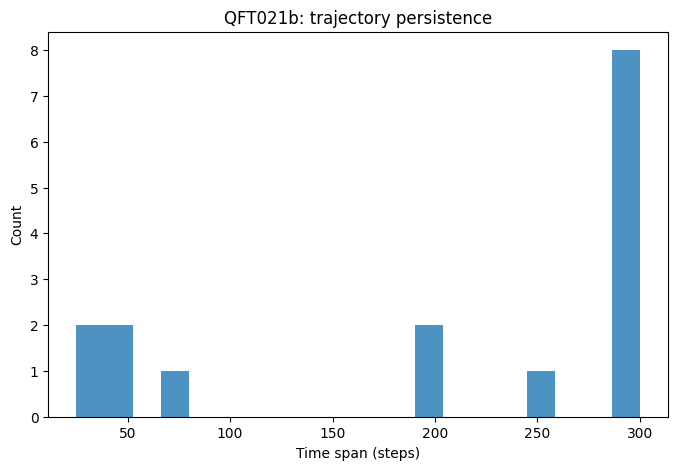

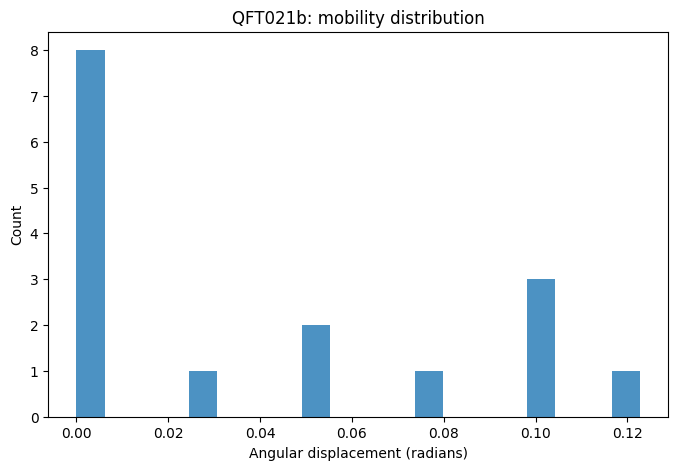

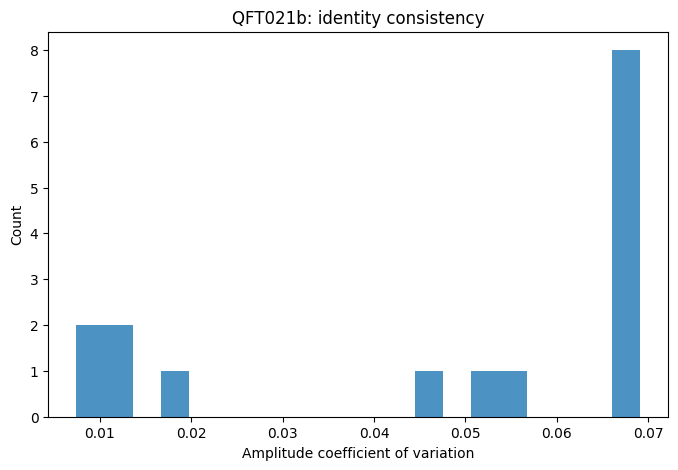

In [ ]:
# Trajectory plot (indices over snapshot time)
plt.figure(figsize=(10,6))
for tr in trajectories[:50]:  # show first 50 for clarity
    plt.plot(tr['times'], tr['indices'], alpha=0.6)
plt.xlabel("Snapshot index")
plt.ylabel("Position (grid index)")
plt.title("QFT021b: particle trajectories across snapshots")
plt.show()

# Persistence histogram (time span)
plt.figure(figsize=(8,5))
plt.hist(spans, bins=20, alpha=0.8)
plt.xlabel("Time span (steps)")
plt.ylabel("Count")
plt.title("QFT021b: trajectory persistence")
plt.show()

# Displacement histogram (radians)
plt.figure(figsize=(8,5))
plt.hist(displacements, bins=20, alpha=0.8)
plt.xlabel("Angular displacement (radians)")
plt.ylabel("Count")
plt.title("QFT021b: mobility distribution")
plt.show()

# Identity consistency (CV) histogram
plt.figure(figsize=(8,5))
plt.hist(consistency, bins=20, alpha=0.8)
plt.xlabel("Amplitude coefficient of variation")
plt.ylabel("Count")
plt.title("QFT021b: identity consistency")
plt.show()


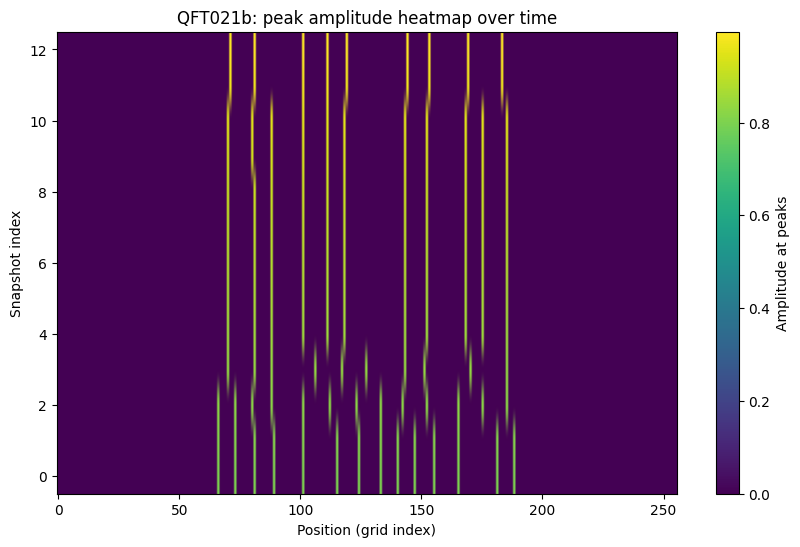

In [ ]:
# Build a peak-amplitude matrix (time x position) for quick inspection
peak_matrix = np.zeros((len(snapshots), N_grid))
for t, idxs in enumerate(peaks_list):
    peak_matrix[t, idxs] = snapshots[t][idxs]

plt.figure(figsize=(10,6))
plt.imshow(peak_matrix, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Amplitude at peaks')
plt.xlabel("Position (grid index)")
plt.ylabel("Snapshot index")
plt.title("QFT021b: peak amplitude heatmap over time")
plt.show()
